# Fase 7 — Comparación de configuraciones

Hasta acá hubo **una** corrida. Esta fase mueve dos hiperparámetros y mide qué
pasa, para decidir con datos hacia dónde conviene escalar.

## Diseño del experimento

Un factorial 2×2: dimensión ∈ {50, 100} × contexto ∈ {2, 5}. Todo lo demás se
mantiene **fijo a propósito**, así cualquier diferencia es atribuible a la
variable que movimos:

| Fijo | Valor |
|---|---|
| vocabulario | el mismo `vocab.json` de 5.000 palabras, construido sobre el corpus completo (`vocab_from`) |
| corpus | las mismas 2M de oraciones de `muestra_2m.txt` |
| épocas / batch / lr / negativos / semilla | 15 / 512 / 0,003 / 10 / 42 |

| Corrida | dim | contexto |
|---|---|---|
| `piloto_5k_50_2` | 50 | 2 |
| `piloto_5k_100_2` | 100 | 2 |
| `piloto_5k_50_5` | 50 | 5 |
| `piloto_5k_100_5` | 100 | 5 |

Y aparte una **ablación**: `ablacion_unk_5k_50_2`, idéntica a la primera salvo
que entrena **con `<UNK>`** en vez de descartar los OOV.

## Cómo se va a comparar (y cómo no)

Tres precauciones, porque las tres son fáciles de pasar por alto:

1. **La loss no cruza tamaños de contexto.** Predecir el target desde 10
   palabras es una tarea *más fácil* que desde 4: la corrida de contexto 5 va a
   tener menor loss aunque no haya aprendido nada mejor. La loss sirve para
   comparar dimensión (misma tarea), no contexto.

2. **La precisión en analogías tiene ruido.** Son 286 ítems; al 41% el intervalo
   de confianza del 95% mide ±6 puntos. Se reportan intervalos de Wilson junto a
   cada porcentaje.

3. **Comparar dos porcentajes desperdicia información.** Los modelos responden
   *las mismas* 286 analogías, así que corresponde una prueba **pareada**: la de
   McNemar, que mira solo los ítems donde discrepan. Es bastante más sensible.

In [1]:
import sys
from pathlib import Path

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src").is_dir())
sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np

from src.compare import GRID, collect, cross_validation_loss, mcnemar, run_summary
from src.config import load_config
from src.evaluate import load_embeddings, nearest_neighbors

plt.rcParams["figure.dpi"] = 110

# Una pasada: hiperparámetros, curvas, tiempos y calidad de las cuatro corridas.
FILAS = {f["name"]: f for f in collect(GRID)}
CATEGORIAS = list(FILAS[GRID[0]]["categories"])

ETIQUETA = {
    "piloto_5k_50_2":  "dim 50 · ctx 2",
    "piloto_5k_100_2": "dim 100 · ctx 2",
    "piloto_5k_50_5":  "dim 50 · ctx 5",
    "piloto_5k_100_5": "dim 100 · ctx 5",
}
COLOR = {"piloto_5k_50_2": "#7f8c9b", "piloto_5k_100_2": "#2a6f97",
         "piloto_5k_50_5": "#c9a227", "piloto_5k_100_5": "#8b3a3a"}


def aciertos(nombre, categoria=None):
    """Resultado ítem por ítem, para las pruebas pareadas."""
    return [h for cat, *_, h in FILAS[nombre]["items"]
            if categoria is None or cat == categoria]


for nombre in GRID:
    f = FILAS[nombre]
    lo, hi = f["accuracy_ci"]
    print(f"{ETIQUETA[nombre]:<16} loss {f['val_loss']:.4f} | "
          f"analogías {f['accuracy']:5.1%} [{lo:.1%}, {hi:.1%}] | "
          f"{f['seconds_per_epoch']/60:.1f} min/época | "
          f"{f['params']:,} parámetros")

dim 50 · ctx 2   loss 2.6430 | analogías 41.3% [35.7%, 47.0%] | 3.8 min/época | 500,000 parámetros
dim 100 · ctx 2  loss 2.6128 | analogías 54.2% [48.4%, 59.9%] | 2.6 min/época | 1,000,000 parámetros
dim 50 · ctx 5   loss 2.6183 | analogías 42.3% [36.7%, 48.1%] | 2.7 min/época | 500,000 parámetros
dim 100 · ctx 5  loss 2.5905 | analogías 49.7% [43.9%, 55.4%] | 2.8 min/época | 1,000,000 parámetros


---

## 1. El panorama

A la izquierda, la precisión de cada configuración con su intervalo de confianza.
A la derecha, el mismo dato como **gráfico de interacción**: dos líneas (una por
dimensión) sobre el eje del contexto. Si las líneas fueran paralelas, los dos
efectos serían independientes y se sumarían. No lo son — y ahí está el resultado
más interesante de la fase.

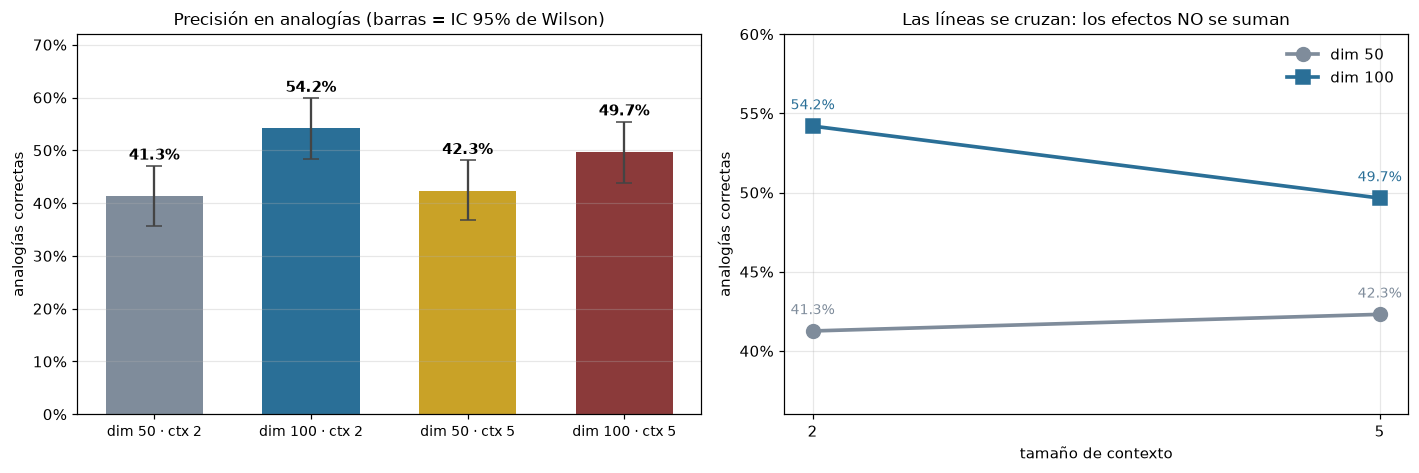

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))

# --- izquierda: precisión con IC de Wilson ---
ax = axes[0]
nombres = list(GRID)
valores = [FILAS[n]["accuracy"] for n in nombres]
bajo = [FILAS[n]["accuracy"] - FILAS[n]["accuracy_ci"][0] for n in nombres]
alto = [FILAS[n]["accuracy_ci"][1] - FILAS[n]["accuracy"] for n in nombres]

barras = ax.bar(range(4), valores, color=[COLOR[n] for n in nombres],
                yerr=[bajo, alto], capsize=5, ecolor="#444", width=0.62)
for i, (n, v) in enumerate(zip(nombres, valores)):
    ax.text(i, v + alto[i] + 0.012, f"{v:.1%}", ha="center", fontweight="bold")
ax.set_xticks(range(4))
ax.set_xticklabels([ETIQUETA[n] for n in nombres], fontsize=9)
ax.set_ylabel("analogías correctas")
ax.set_title("Precisión en analogías (barras = IC 95% de Wilson)", fontsize=11)
ax.set_ylim(0, 0.72)
ax.yaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
ax.grid(axis="y", alpha=0.3)

# --- derecha: interacción dim x contexto ---
ax = axes[1]
for dim, color, marca in [(50, "#7f8c9b", "o"), (100, "#2a6f97", "s")]:
    ys = [FILAS[f"piloto_5k_{dim}_{c}"]["accuracy"] for c in (2, 5)]
    ax.plot([2, 5], ys, marker=marca, markersize=9, linewidth=2.4,
            color=color, label=f"dim {dim}")
    for x, y in zip((2, 5), ys):
        ax.annotate(f"{y:.1%}", (x, y), textcoords="offset points",
                    xytext=(0, 11), ha="center", fontsize=9, color=color)
ax.set_xticks([2, 5])
ax.set_xlabel("tamaño de contexto")
ax.set_ylabel("analogías correctas")
ax.set_title("Las líneas se cruzan: los efectos NO se suman", fontsize=11)
ax.set_ylim(0.36, 0.60)
ax.yaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
ax.legend(frameon=False)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

Dos lecturas inmediatas:

- **Subir la dimensión funciona**, y bastante: de 41,3% a 54,2% con contexto 2.
- **Subir el contexto no**. Con dim 50 apenas se mueve, y con dim 100 **empeora**.

Los intervalos de la izquierda ya sugieren cuál de esas diferencias es real, pero
como los cuatro modelos respondieron las mismas analogías, la prueba correcta es
la pareada.

---

## 2. Efecto de la dimensión: 50 → 100

McNemar solo mira los ítems donde los dos modelos **discrepan**. Si fueran
equivalentes, cada desacuerdo sería una moneda al aire y los dos números de abajo
deberían parecerse.

In [3]:
def comparar(a, b, titulo):
    """McNemar global y por categoría entre dos corridas."""
    ga, gb = FILAS[a]["accuracy"], FILAS[b]["accuracy"]
    t = mcnemar(aciertos(a), aciertos(b))
    print(titulo)
    print(f"  {ETIQUETA[a]}  ->  {ETIQUETA[b]}")
    print(f"  GLOBAL  {ga:.1%} -> {gb:.1%}  ({(gb-ga)*100:+.1f} pp)")
    print(f"    solo acierta A: {t['solo_a']:>3}   solo acierta B: {t['solo_b']:>3}"
          f"   -> p = {t['p_value']:.4f}" + ("  SIGNIFICATIVO" if t['p_value'] < 0.05 else ""))
    print(f"  {'por categoría':<26} {'A':>7} {'B':>7} {'delta':>8} {'p':>8}")
    for cat in CATEGORIAS:
        da, db = FILAS[a]["categories"][cat], FILAS[b]["categories"][cat]
        tc = mcnemar(aciertos(a, cat), aciertos(b, cat))
        marca = " *" if tc["p_value"] < 0.05 else ""
        print(f"    {cat:<24} {da['accuracy']:>7.1%} {db['accuracy']:>7.1%} "
              f"{(db['accuracy']-da['accuracy'])*100:>+7.1f} pp {tc['p_value']:>7.4f}{marca}")
    print()
    return t


_ = comparar("piloto_5k_50_2", "piloto_5k_100_2", "EFECTO DIMENSIÓN, con contexto 2")
_ = comparar("piloto_5k_50_5", "piloto_5k_100_5", "EFECTO DIMENSIÓN, con contexto 5")

EFECTO DIMENSIÓN, con contexto 2
  dim 50 · ctx 2  ->  dim 100 · ctx 2
  GLOBAL  41.3% -> 54.2%  (+12.9 pp)
    solo acierta A:   8   solo acierta B:  45   -> p = 0.0000  SIGNIFICATIVO
  por categoría                    A       B    delta        p
    género                     61.1%   74.4%   +13.3 pp  0.0042 *
    plural                     27.8%   38.9%   +11.1 pp  0.0213 *
    verbo: presente → pasado   19.6%   39.3%   +19.6 pp  0.0034 *
    país → gentilicio          76.7%   96.7%   +20.0 pp  0.0312 *
    adjetivo → adverbio        20.0%   10.0%   -10.0 pp  0.5000

EFECTO DIMENSIÓN, con contexto 5
  dim 50 · ctx 5  ->  dim 100 · ctx 5
  GLOBAL  42.3% -> 49.7%  (+7.3 pp)
    solo acierta A:   6   solo acierta B:  27   -> p = 0.0003  SIGNIFICATIVO
  por categoría                    A       B    delta        p
    género                     57.8%   65.6%    +7.8 pp  0.0391 *
    plural                     31.1%   34.4%    +3.3 pp  0.5488
    verbo: presente → pasado   19.6%   33.9%  

El efecto es grande y consistente: **+12,9 puntos** con contexto 2 (p < 0,0001) y
**+7,3** con contexto 5 (p = 0,0003). Con contexto 2 mejora en **cuatro de las
cinco categorías** con significancia individual.

Lo más notable es *dónde* mejora. Las categorías morfológicas, que eran la
debilidad del modelo, son las que más suben:

- verbo presente→pasado: 19,6% → **39,3%** (se duplica)
- plural: 27,8% → **38,9%**

Duplicar la dimensión duplica los parámetros (500.000 → 1.000.000) y el archivo
exportado (2,3 → 4,6 MB), pero **no cuesta tiempo**. Las tres corridas nuevas se
ejecutaron una tras otra en idénticas condiciones y las tres rondan los 2,6-2,8
min/época, sin importar la dimensión ni el contexto. El cuello de botella es la
CPU generando pares —el mismo trabajo en las cuatro— y no la GPU multiplicando
matrices, así que 50 dimensiones extra salen gratis en la práctica.

---

## 3. Efecto del contexto: 2 → 5

Acá esperaba lo contrario de lo que pasó, así que vale la pena mirarlo con
cuidado.

In [4]:
_ = comparar("piloto_5k_50_2", "piloto_5k_50_5", "EFECTO CONTEXTO, con dim 50")
_ = comparar("piloto_5k_100_2", "piloto_5k_100_5", "EFECTO CONTEXTO, con dim 100")

EFECTO CONTEXTO, con dim 50
  dim 50 · ctx 2  ->  dim 50 · ctx 5
  GLOBAL  41.3% -> 42.3%  (+1.0 pp)
    solo acierta A:   9   solo acierta B:  12   -> p = 0.6636
  por categoría                    A       B    delta        p
    género                     61.1%   57.8%    -3.3 pp  0.3750
    plural                     27.8%   31.1%    +3.3 pp  0.5078
    verbo: presente → pasado   19.6%   19.6%    +0.0 pp  1.0000
    país → gentilicio          76.7%   90.0%   +13.3 pp  0.1250
    adjetivo → adverbio        20.0%   15.0%    -5.0 pp  1.0000

EFECTO CONTEXTO, con dim 100
  dim 100 · ctx 2  ->  dim 100 · ctx 5
  GLOBAL  54.2% -> 49.7%  (-4.5 pp)
    solo acierta A:  23   solo acierta B:  10   -> p = 0.0351  SIGNIFICATIVO
  por categoría                    A       B    delta        p
    género                     74.4%   65.6%    -8.9 pp  0.0574
    plural                     38.9%   34.4%    -4.4 pp  0.3877
    verbo: presente → pasado   39.3%   33.9%    -5.4 pp  0.3750
    país → gentil

- **Con dim 50 el contexto no hace nada**: +1,0 punto, p = 0,66. Indistinguible
  de no haber cambiado nada.
- **Con dim 100 el contexto hace daño**: −4,5 puntos, p = 0,035. Las tres
  categorías morfológicas bajan y ninguna sube de forma significativa.

La única categoría que se beneficia de una ventana más ancha es
**país → gentilicio**, y solo cuando hay lugar para mejorar: con dim 50 sube de
76,7% a 90,0%. Con dim 100 ya estaba en 96,7% y no puede subir más.

Eso encaja con un patrón conocido en la literatura (Mikolov et al.; Levy &
Goldberg): **ventanas anchas capturan relaciones temáticas** —"argentina" y
"argentino" aparecen en los mismos textos, aunque lejos— mientras que **ventanas
angostas capturan relaciones de forma**, porque el vecino inmediato es el que
lleva la información sintáctica. Ensanchar la ventana cambia una cosa por la
otra.

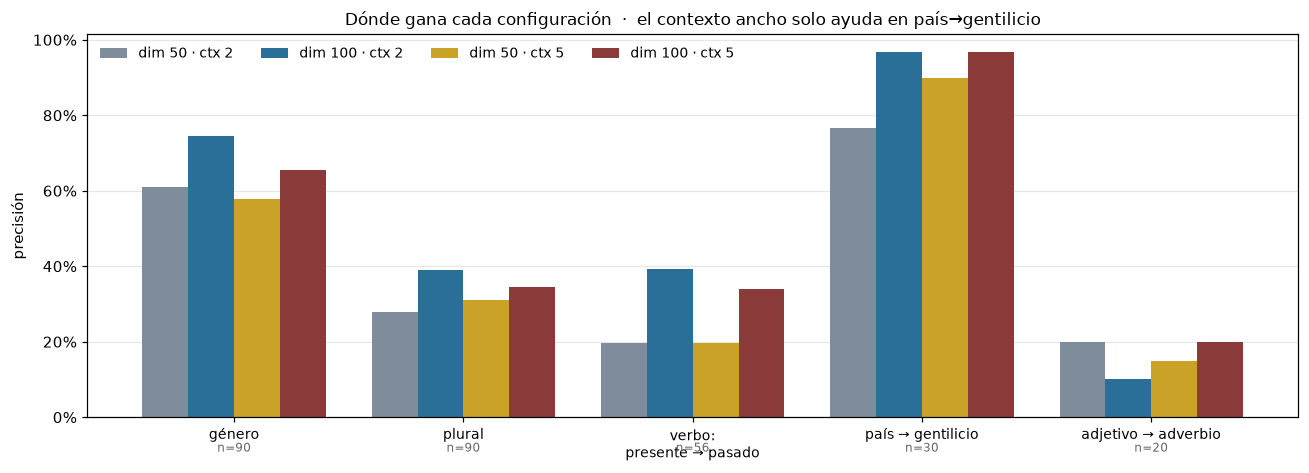

In [5]:
fig, ax = plt.subplots(figsize=(12, 4.4))

x = np.arange(len(CATEGORIAS))
ancho = 0.2
for i, nombre in enumerate(GRID):
    valores = [FILAS[nombre]["categories"][c]["accuracy"] for c in CATEGORIAS]
    ax.bar(x + (i - 1.5) * ancho, valores, ancho,
           label=ETIQUETA[nombre], color=COLOR[nombre])

ax.set_xticks(x)
ax.set_xticklabels([c.replace(": ", ":\n") for c in CATEGORIAS], fontsize=9)
ax.set_ylabel("precisión")
ax.yaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
ax.set_title("Dónde gana cada configuración  ·  el contexto ancho solo ayuda en "
             "país→gentilicio", fontsize=11)
ax.legend(frameon=False, ncol=4, fontsize=9)
ax.grid(axis="y", alpha=0.3)
ax.set_axisbelow(True)

# n de cada categoría: el ruido no es igual en todas
for xi, cat in zip(x, CATEGORIAS):
    ax.text(xi, -0.09, f"n={FILAS[GRID[0]]['categories'][cat]['evaluated']}",
            ha="center", fontsize=8, color="#666", transform=ax.get_xaxis_transform())

plt.tight_layout()
plt.show()

> **Cuidado con `adjetivo → adverbio`**: son 20 ítems. Un cambio de 10 puntos son
> 2 analogías. Ninguna de sus diferencias resultó significativa y no conviene
> leerlas.

---

## 4. Una hipótesis que el experimento refutó

Al cerrar la Fase 6 dejé escrita esta predicción:

> *"El perfil es informativo: las relaciones temáticas se resuelven bien y las
> morfológicas no. Es consistente con `context_size=2` —una ventana chica captura
> de qué se habla, no la sintaxis— y es una hipótesis directamente comprobable
> subiendo el contexto a 5 o 10 en la Fase 7."*

**Estaba equivocada, y en los dos sentidos.** El experimento dice que:

1. Subir el contexto **no** arregló la morfología: con dim 100 la empeoró.
2. La causa real de la debilidad morfológica era la **dimensión**. Con 50
   dimensiones el modelo no tenía capacidad para codificar a la vez el tema y la
   forma de cada palabra; con 100 la morfología casi se duplica sin tocar la
   ventana.
3. El razonamiento de fondo también estaba al revés: una ventana chica captura
   **más** sintaxis, no menos.

Vale la pena dejarlo escrito así. La predicción era falsable, se puso a prueba y
salió mal — que es exactamente para lo que sirve montar la grilla en vez de
razonar de memoria.

---

## 5. Curvas de loss

Se grafican **agrupadas por tarea**: las dos corridas de contexto 2 comparten un
panel y las de contexto 5 otro. Comparar entre paneles no significa nada, porque
predecir desde 10 palabras es más fácil que desde 4 y la loss baja por eso solo.

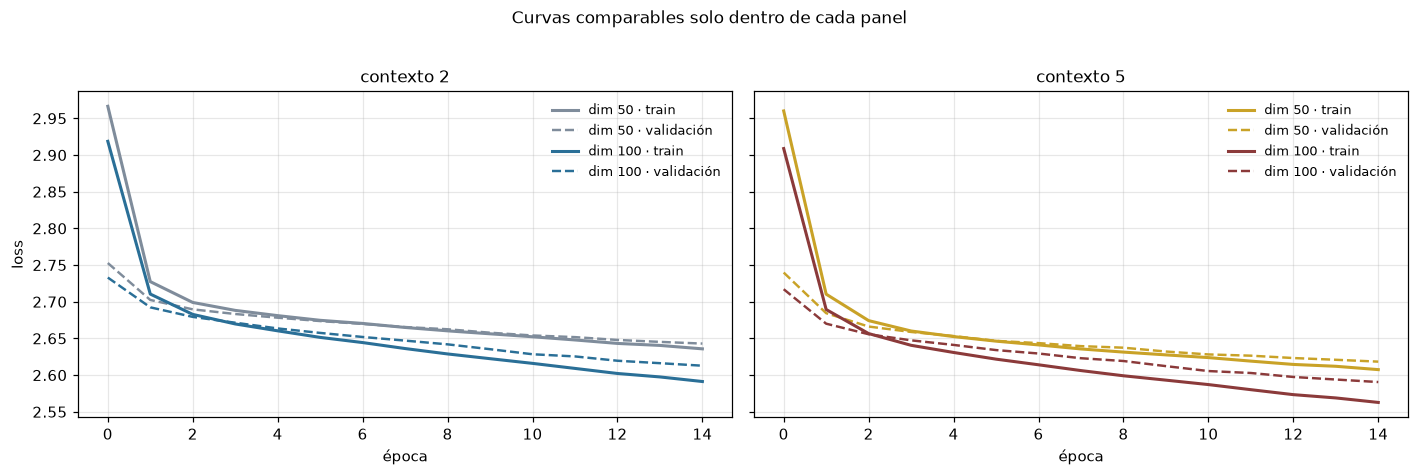

loss de validación final
  dim 50 · ctx 2   2.6430
  dim 100 · ctx 2  2.6128
  dim 50 · ctx 5   2.6183
  dim 100 · ctx 5  2.5905

Dentro de contexto 2: dim 100 baja la loss (2,6430 -> 2,6128) Y sube las
analogías. Los dos indicadores coinciden, que es lo que uno espera.
Dentro de contexto 5: dim 100 también baja la loss (2,6183 -> 2,5905).

Pero ojo: 5k_100_5 tiene la loss MÁS BAJA de las cuatro (2,5905) y NO es
la mejor en analogías (49,7% contra 54,2%). Menor loss no es mejor modelo:
mide qué tan bien predice palabras, no qué tan útil es el espacio vectorial.


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2), sharey=True)

for ax, ctx in zip(axes, (2, 5)):
    for dim in (50, 100):
        nombre = f"piloto_5k_{dim}_{ctx}"
        historia = FILAS[nombre]["history"]
        epocas = [r["epoch"] for r in historia]
        ax.plot(epocas, [r["train_loss"] for r in historia],
                color=COLOR[nombre], linewidth=2, label=f"dim {dim} · train")
        ax.plot(epocas, [r["val_loss"] for r in historia],
                color=COLOR[nombre], linewidth=1.6, linestyle="--",
                label=f"dim {dim} · validación")
    ax.set_title(f"contexto {ctx}", fontsize=11)
    ax.set_xlabel("época")
    ax.grid(alpha=0.3)
    ax.legend(frameon=False, fontsize=8.5)

axes[0].set_ylabel("loss")
fig.suptitle("Curvas comparables solo dentro de cada panel", fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

print("loss de validación final")
for nombre in GRID:
    print(f"  {ETIQUETA[nombre]:<16} {FILAS[nombre]['val_loss']:.4f}")
print()
print("Dentro de contexto 2: dim 100 baja la loss (2,6430 -> 2,6128) Y sube las")
print("analogías. Los dos indicadores coinciden, que es lo que uno espera.")
print("Dentro de contexto 5: dim 100 también baja la loss (2,6183 -> 2,5905).")
print()
print("Pero ojo: 5k_100_5 tiene la loss MÁS BAJA de las cuatro (2,5905) y NO es")
print("la mejor en analogías (49,7% contra 54,2%). Menor loss no es mejor modelo:")
print("mide qué tan bien predice palabras, no qué tan útil es el espacio vectorial.")

Ese último punto merece subrayarse: **`5k_100_5` gana en loss y pierde en
analogías**. Si hubiéramos elegido la configuración mirando solo la curva de
entrenamiento, habríamos elegido mal. La loss es la función que optimizamos; la
calidad de los embeddings es lo que nos importa, y no son lo mismo.

---

## 6. Vecinos cercanos, lado a lado

El control cualitativo: ¿se nota la diferencia leyendo?

In [7]:
CARGADOS = [(n, *load_embeddings(load_config(f"configs/{n}.yaml"))) for n in GRID]

for palabra in ["febrero", "mujer", "dijo", "ciudades", "italia"]:
    print(f"\n{palabra}")
    for nombre, emb, voc in CARGADOS:
        vecinos = nearest_neighbors(palabra, emb, voc, k=6)
        print(f"  {ETIQUETA[nombre]:<16} " + ", ".join(w for w, _ in vecinos))


febrero
  dim 50 · ctx 2   marzo, abril, octubre, mayo, julio, junio
  dim 100 · ctx 2  marzo, abril, mayo, octubre, junio, julio
  dim 50 · ctx 5   marzo, abril, octubre, julio, junio, mayo
  dim 100 · ctx 5  marzo, abril, mayo, junio, octubre, julio

mujer
  dim 50 · ctx 2   niña, infancia, niño, hermosa, vida, amiga
  dim 100 · ctx 2  niña, niño, mujeres, infancia, hermosa, familia
  dim 50 · ctx 5   niña, infancia, niño, vida, mujeres, femenina
  dim 100 · ctx 5  mujeres, igualdad, niña, infancia, hermosa, niño

dijo
  dim 50 · ctx 2   decía, sabía, dijeron, dije, llamó, dijiste
  dim 100 · ctx 2  sabía, dije, decía, pensaba, dijeron, creía
  dim 50 · ctx 5   decía, sabía, dijeron, dije, quería, dijiste
  dim 100 · ctx 5  sabía, dije, creía, dijiste, decía, dijeron

ciudades
  dim 50 · ctx 2   localidades, rutas, ciudad, provincias, calles, carreteras
  dim 100 · ctx 2  localidades, provincias, ciudad, rutas, barrios, carreteras
  dim 50 · ctx 5   localidades, rutas, provincias, c

Acá la diferencia es mucho menos dramática que en las analogías: las cuatro
configuraciones agrupan bien los meses, los verbos y los plurales. Tiene sentido
—los vecinos cercanos son una prueba fácil, que ya pasaba la corrida de 50
dimensiones— y es la razón por la que hace falta una métrica numérica: **para
elegir entre configuraciones que "a ojo" se parecen**.

---

## 7. El costo

> Los 3,8 min/época de la línea de base se midieron en otra sesión y **no** son
> comparables con los de las otras tres, que corrieron encadenadas. La lectura
> válida es entre esas tres: 2,6 / 2,7 / 2,8 min, es decir, ni la dimensión ni el
> contexto mueven el tiempo.

In [8]:
print(f"{'corrida':<16} {'parámetros':>12} {'min/época':>10} {'total':>9} "
      f"{'checkpoint':>11} {'.txt':>8} {'.bin':>8}")
print("-" * 80)
for nombre in GRID:
    f = FILAS[nombre]
    print(f"{ETIQUETA[nombre]:<16} {f['params']:>12,} "
          f"{f['seconds_per_epoch']/60:>10.1f} {f['seconds_total']/60:>7.0f}m "
          f"{f['checkpoint_bytes']/1024**2:>9.1f}MB "
          f"{f['embeddings_txt_bytes']/1024**2:>6.1f}MB "
          f"{f['embeddings_bin_bytes']/1024**2:>6.1f}MB")

print()
print("El tiempo por época NO crece con la dimensión ni con el contexto: las tres")
print("corridas nuevas rondan los 2,6-2,8 min. Lo que domina es la CPU generando")
print("pares (el mismo trabajo en las cuatro), no la GPU. La dimensión sale gratis")
print("en tiempo y solo cuesta disco.")

corrida            parámetros  min/época     total  checkpoint     .txt     .bin
--------------------------------------------------------------------------------
dim 50 · ctx 2        500,000        3.8      57m       5.7MB    2.3MB    1.0MB
dim 100 · ctx 2     1,000,000        2.6      39m      11.4MB    4.6MB    1.9MB
dim 50 · ctx 5        500,000        2.7      40m       5.7MB    2.3MB    1.0MB
dim 100 · ctx 5     1,000,000        2.8      41m      11.4MB    4.6MB    1.9MB

El tiempo por época NO crece con la dimensión ni con el contexto: las tres
corridas nuevas rondan los 2,6-2,8 min. Lo que domina es la CPU generando
pares (el mismo trabajo en las cuatro), no la GPU. La dimensión sale gratis
en tiempo y solo cuesta disco.


---

# 8. Ablación: entrenar **con** `<UNK>`

Hasta acá, todas las corridas usan `drop_unknown: true`: las palabras fuera del
vocabulario se **eliminan** de la oración. La alternativa es convertirlas en un
token comodín `<UNK>` que entra al entrenamiento como cualquier otra palabra.

`ablacion_unk_5k_50_2` es idéntica a `piloto_5k_50_2` salvo por esa bandera.

## 8.1 Primero: ¿cuánto `<UNK>` ve realmente el modelo?

Antes de interpretar cualquier resultado hay que saber la magnitud de lo que
cambiamos. `<UNK>` es el 16,7% del corpus, pero el subsampling lo castiga
justamente por ser frecuente.

In [9]:
from collections import Counter

from src.config import corpus_path, vocab_path
from src.corpus import stream_tokens
from src.dataset import generate_pairs
from src.vocabulary import Vocabulary

CFG_UNK = load_config("configs/ablacion_unk_5k_50_2.yaml")
CFG_BASE = load_config("configs/piloto_5k_50_2.yaml")
VOCAB = Vocabulary.load(vocab_path(CFG_UNK))
N = 100_000

# Antes del subsampling: la oración tal como sale del tokenizador.
crudo = Counter()
for tokens in stream_tokens(corpus_path(CFG_UNK), limit=N):
    crudo.update(VOCAB.encode(tokens, drop_unknown=False))
total_crudo = sum(crudo.values())

# Después del subsampling: los targets que el modelo realmente ve.
vistos = Counter()
for _contexto, target in generate_pairs(
        corpus_path(CFG_UNK), VOCAB, CFG_UNK["context_size"], limit=N,
        drop_unknown=False,
        subsampling_threshold=CFG_UNK["subsampling_threshold"]):
    vistos[target] += 1
total_vistos = sum(vistos.values())

frecuencia = crudo[0] / total_crudo
print(f"sobre {N:,} oraciones ({total_crudo:,} tokens)")
print(f"  <UNK> en el corpus crudo   : {crudo[0]:>9,}  = {frecuencia:.2%}")
print(f"  <UNK> que sobrevive        : {vistos[0]:>9,}  = {vistos[0]/total_vistos:.2%} del stream")
print(f"  tasa de supervivencia      : {vistos[0]/crudo[0]:.2%}"
      f"   (predicho por sqrt(t/f): {(CFG_UNK['subsampling_threshold']/frecuencia)**0.5:.2%})")
print()
print("los 5 targets más vistos por el modelo:")
for pos, (idx, n) in enumerate(vistos.most_common(5), 1):
    print(f"  {pos}. {VOCAB.word(idx):<8} {n:>7,}  {n/total_vistos:.2%}")

sobre 100,000 oraciones (2,111,519 tokens)
  <UNK> en el corpus crudo   :   353,635  = 16.75%
  <UNK> que sobrevive        :     2,488  = 0.97% del stream
  tasa de supervivencia      : 0.70%   (predicho por sqrt(t/f): 0.77%)

los 5 targets más vistos por el modelo:
  1. <UNK>      2,488  0.97%
  2. de         1,718  0.67%
  3. la         1,299  0.51%
  4. en         1,103  0.43%
  5. y          1,030  0.40%


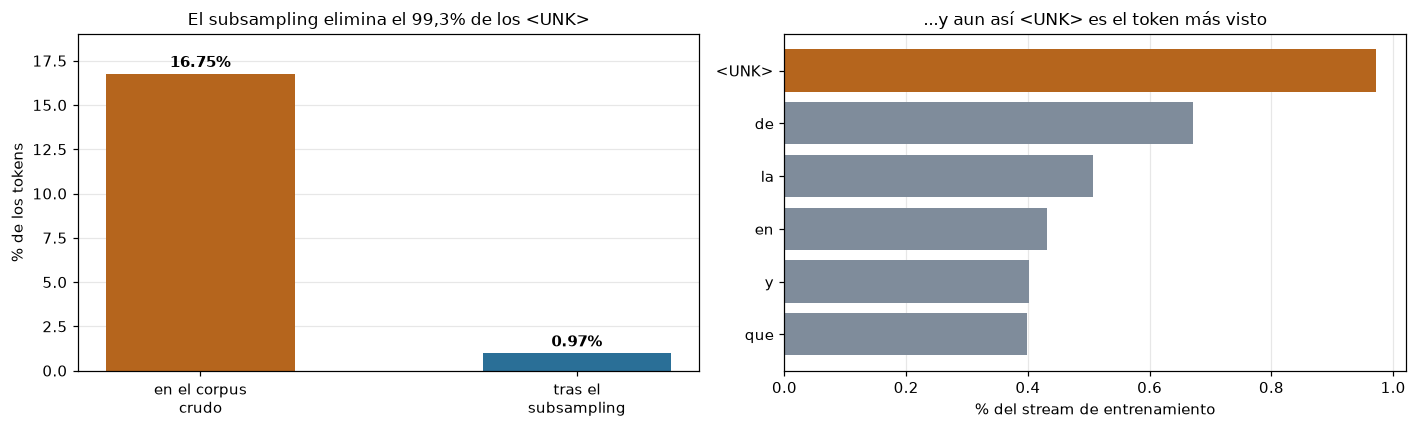

<UNK> queda en 1.45x la frecuencia de 'de',
la palabra más común del español. Es poco en volumen (~1%) pero es lo
primero que el modelo ve. Esa es la magnitud real del cambio.


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# --- izquierda: el embudo del <UNK> ---
ax = axes[0]
etapas = ["en el corpus\ncrudo", "tras el\nsubsampling"]
porcentajes = [frecuencia * 100, vistos[0] / total_vistos * 100]
barras = ax.bar(etapas, porcentajes, color=["#b5651d", "#2a6f97"], width=0.5)
for b, p in zip(barras, porcentajes):
    ax.text(b.get_x() + b.get_width() / 2, p + 0.4, f"{p:.2f}%",
            ha="center", fontweight="bold")
ax.set_ylabel("% de los tokens")
ax.set_title("El subsampling elimina el 99,3% de los <UNK>", fontsize=11)
ax.set_ylim(0, 19)
ax.grid(axis="y", alpha=0.3)
ax.set_axisbelow(True)

# --- derecha: aun así queda primero en el ranking ---
ax = axes[1]
top = vistos.most_common(6)
palabras = [VOCAB.word(i) for i, _ in top]
cuentas = [n / total_vistos * 100 for _, n in top]
colores = ["#b5651d"] + ["#7f8c9b"] * (len(top) - 1)
ax.barh(range(len(top))[::-1], cuentas, color=colores)
ax.set_yticks(range(len(top))[::-1])
ax.set_yticklabels(palabras)
ax.set_xlabel("% del stream de entrenamiento")
ax.set_title("...y aun así <UNK> es el token más visto", fontsize=11)
ax.grid(axis="x", alpha=0.3)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

print(f"<UNK> queda en {vistos[0]/vistos[VOCAB.index('de')]:.2f}x la frecuencia de 'de',")
print("la palabra más común del español. Es poco en volumen (~1%) pero es lo")
print("primero que el modelo ve. Esa es la magnitud real del cambio.")

Ese ~1% es la clave para leer todo lo que sigue: **no estamos comparando dos
modelos muy distintos**. El subsampling ya hacía casi todo el trabajo de sacar
`<UNK>` del medio. La bandera `drop_unknown` decide qué pasa con el 0,7% que
sobrevive.

## 8.2 La loss, y por qué la de esta corrida miente

`ablacion_unk_5k_50_2` termina con una loss de validación **más baja** que la
línea de base. Eso no es aprender mejor: es que su conjunto de validación incluye
`<UNK>`, el token más frecuente que ve el modelo, y predecir el token más
frecuente es fácil.

La comparación honesta es puntuar **los dos modelos sobre la misma validación sin
`<UNK>`**, que es exactamente lo que hace `cross_validation_loss`.

In [11]:
BASE = run_summary("configs/piloto_5k_50_2.yaml")
ABL = run_summary("configs/ablacion_unk_5k_50_2.yaml")

print("loss sobre la validación PROPIA de cada corrida  (NO comparables)")
print(f"  sin <UNK>   {BASE['val_loss']:.4f}")
print(f"  con <UNK>   {ABL['val_loss']:.4f}   <- más baja, pero mide otra tarea")

print()
print("loss de ambos modelos sobre la MISMA validación sin <UNK>  (comparable)")
for etiqueta, cfg in [("sin <UNK>", "configs/piloto_5k_50_2.yaml"),
                      ("con <UNK>", "configs/ablacion_unk_5k_50_2.yaml")]:
    valor = cross_validation_loss(cfg, "configs/piloto_5k_50_2.yaml")
    print(f"  {etiqueta}   {valor:.4f}")

print()
print(f"pares por época: {BASE['pairs_per_epoch']:,} sin <UNK>  vs  "
      f"{ABL['pairs_per_epoch']:,} con <UNK>  "
      f"({ABL['pairs_per_epoch']/BASE['pairs_per_epoch'] - 1:+.2%})")

loss sobre la validación PROPIA de cada corrida  (NO comparables)
  sin <UNK>   2.6430
  con <UNK>   2.6170   <- más baja, pero mide otra tarea

loss de ambos modelos sobre la MISMA validación sin <UNK>  (comparable)


  sin <UNK>   2.6430


  con <UNK>   2.6418

pares por época: 5,009,035 sin <UNK>  vs  5,067,178 con <UNK>  (+1.16%)


Puesta la misma vara: **2,6430 contra 2,6418**. Una diferencia de 0,0012, o sea
nada. La ventaja aparente de la corrida con `<UNK>` era íntegramente el artefacto
que anticipamos.

## 8.3 Analogías: la prueba que importa

In [12]:
hits_base = [h for *_, h in BASE["items"]]
hits_abl = [h for *_, h in ABL["items"]]
prueba = mcnemar(hits_base, hits_abl)

print(f"sin <UNK>   {BASE['accuracy']:.1%} ({BASE['accuracy_correct']}/{BASE['accuracy_evaluated']})")
print(f"con <UNK>   {ABL['accuracy']:.1%} ({ABL['accuracy_correct']}/{ABL['accuracy_evaluated']})")
print()
print(f"McNemar pareado sobre los mismos {len(hits_base)} ítems:")
print(f"  solo acierta sin-<UNK>: {prueba['solo_a']:>3}")
print(f"  solo acierta con-<UNK>: {prueba['solo_b']:>3}")
print(f"  p = {prueba['p_value']:.4f}"
      f"  -> {'diferencia significativa' if prueba['p_value'] < 0.05 else 'NO significativa'}")
print()
print(f"{'categoría':<26} {'sin <UNK>':>10} {'con <UNK>':>10} {'p':>8}")
for cat in CATEGORIAS:
    b, a = BASE["categories"][cat], ABL["categories"][cat]
    tc = mcnemar([h for c, *_, h in BASE["items"] if c == cat],
                 [h for c, *_, h in ABL["items"] if c == cat])
    marca = " *" if tc["p_value"] < 0.05 else ""
    print(f"{cat:<26} {b['accuracy']:>10.1%} {a['accuracy']:>10.1%} "
          f"{tc['p_value']:>8.4f}{marca}")

sin <UNK>   41.3% (118/286)
con <UNK>   44.4% (127/286)

McNemar pareado sobre los mismos 286 ítems:
  solo acierta sin-<UNK>:  13
  solo acierta con-<UNK>:  22
  p = 0.1755  -> NO significativa

categoría                   sin <UNK>  con <UNK>        p
género                          61.1%      61.1%   1.0000
plural                          27.8%      30.0%   0.7905
verbo: presente → pasado        19.6%      19.6%   1.0000
país → gentilicio               76.7%     100.0%   0.0156 *
adjetivo → adverbio             20.0%      20.0%   1.0000


## 8.4 Qué dice el experimento, y qué no

Lo que se midió, sin adornos:

| | sin `<UNK>` | con `<UNK>` | ¿diferencia real? |
|---|---|---|---|
| loss sobre la misma validación | 2,6430 | 2,6418 | no (0,0012) |
| analogías | 41,3% | 44,4% | **no** (McNemar p = 0,18) |
| pares por época | 5.009.035 | 5.067.178 | +1,16% |

**El experimento no respalda la afirmación de que sea mejor entrenar sin
`<UNK>`.** Las dos configuraciones son estadísticamente indistinguibles, y el
único movimiento apreciable (país → gentilicio, 76,7% → 100%) va *a favor* de
`<UNK>` — pero es una categoría de 30 ítems, y con cinco categorías puestas a
prueba, un p = 0,016 aislado es lo que se espera por azar.

La razón de fondo es la que medimos en 8.1: **el subsampling ya elimina el 99,3%
de los `<UNK>`**. Con `drop_unknown` estamos decidiendo el destino del 0,7% que
queda. Es un cambio demasiado chico para mover la aguja.

Entonces, ¿por qué conservar `drop_unknown: true` como opción por defecto? Los
argumentos que quedan en pie son de **costo y de higiene**, no de calidad, y
conviene enunciarlos como tales:

1. **Cuesta un 1,16% más de cómputo** por época a cambio de una mejora que no se
   puede distinguir de cero.
2. **Vuelve la loss engañosa.** Como se vio en 8.2, la curva de validación deja
   de significar lo mismo y hay que montar una evaluación cruzada para comparar
   con cualquier otra corrida. Es una complicación permanente por un beneficio
   nulo.
3. **`<UNK>` no es una palabra.** Su vector agrega una fila al espacio que no
   representa nada en particular —es el promedio de todo lo que quedó afuera— y
   hay que acordarse de excluirla en cada consulta de vecinos y en la
   exportación.

Y el argumento que **hay que retirar**: en la Fase 6 escribí que dejar `<UNK>`
haría que el modelo "gastara capacidad prediciendo un token comodín". A 0,97% del
stream, esa capacidad es despreciable, y la medición lo confirma. No era el
motivo.

> Este resultado es el que menos esperaba de la fase, y es el que más vale la
> pena haber corrido: la práctica que veníamos usando no está mal, pero la
> justificación que le habíamos puesto sí lo estaba.

---

# 9. Conclusiones

**Qué escalar primero: la dimensión.** Es el único factor que produjo una mejora
grande e inequívoca (+12,9 pp, p < 0,0001), arregla justamente la debilidad
morfológica del modelo, y es **gratis en tiempo de entrenamiento** —el cuello de
botella es la CPU generando pares, no la GPU—. Solo cuesta disco.

**Qué no escalar: el contexto.** Con dim 50 no aportó nada (p = 0,66) y con dim
100 hizo daño (−4,5 pp, p = 0,035). Un contexto ancho solo ayudó en la única
categoría temática, y únicamente mientras hubo margen para mejorar.

**Sobre `<UNK>`:** la decisión importa mucho menos de lo que suponíamos, porque
el subsampling ya resuelve el 99,3% del problema. Se mantiene `drop_unknown:
true` por costo y simplicidad, no por calidad.

## La configuración recomendada

`piloto_5k_100_2` — **dim 100, contexto 2**: 54,2% en analogías, la mejor de las
cuatro, y la más barata en tiempo junto con las demás.

